11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000, Test samples: 10000
Image shape: (28, 28, 1), Classes: [0 1 2 3 4 5 6 7 8 9]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 64s 36ms/step - accuracy: 0.9579 - loss: 0.1368 - val_accuracy: 0.9857 - val_loss: 0.0478
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.9859 - loss: 0.0459 - val_accuracy: 0.9890 - val_loss: 0.0389
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.9894 - loss: 0.0309 - val_accuracy: 0.9908 - val_loss: 0.0351
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.9927 - loss: 0.0224 - val_accuracy: 0.9923 - val_loss: 0.0284
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9942 - loss: 0.0174 - val_accuracy: 0.9903 - val_loss: 0.0368
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9958 - loss: 0.0129 - val_accuracy: 0.9912 - val_loss: 0.0407
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9964 - loss: 0.0104 - val_accuracy: 0.9918 - val_loss: 0.0432
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9969 -

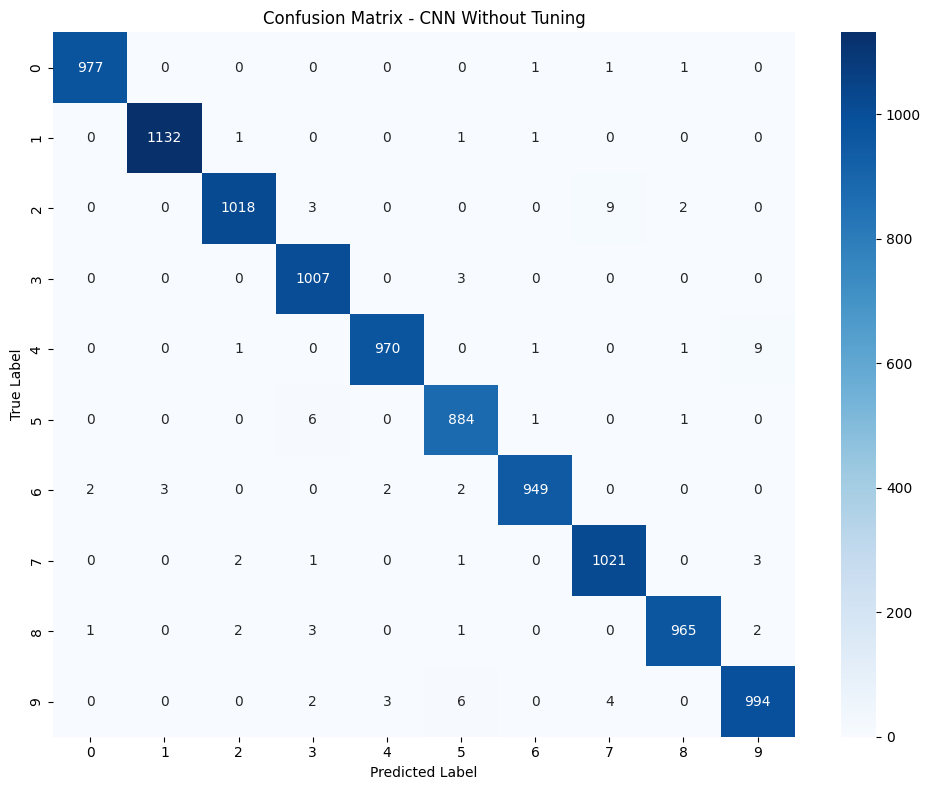

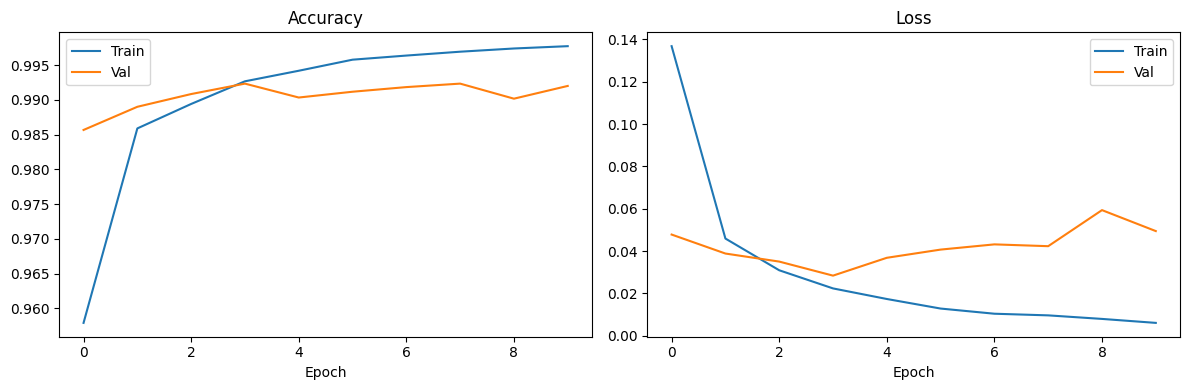

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Image shape: {X_train.shape[1:]}, Classes: {np.unique(y_train)}")

# Build CNN
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train
history = model.fit(X_train, y_train, epochs=10, batch_size=32,
                    validation_split=0.1, verbose=1)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - CNN Without Tuning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout()
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting hyperparameter search (10 trials)...

Best Hyperparameters:
  filters_1     : 64
  filters_2     : 128
  dense_units   : 64
  dropout       : 0.2
  learning_rate : 0.001
Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 121s 71ms/step - accuracy: 0.9489 - loss: 0.1693 - val_accuracy: 0.9858 - val_loss: 0.0504
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 141s 71ms/step - accuracy: 0.9821 - loss: 0.0601 - val_accuracy: 0.9900 - val_loss: 0.0407
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 122s 73ms/step - accuracy: 0.9872 - loss: 0.0421 - val_accuracy: 0.9890 - val_loss: 0.0393
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 138s 70ms/step - accuracy: 0.9901 - loss: 0.0315 - val_accuracy: 0.9903 - val_loss: 0.0386
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 119s 70ms/step - accuracy: 0.9920 - loss: 0.0246 - val_accuracy: 0.9915 - val_loss: 0.0300
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 130s 77ms/step - accuracy: 0.9932 - loss: 0.0218 - val_accuracy: 0.9912 - val_loss: 0.0325
Epoch 7/15
1688/1688 ━━

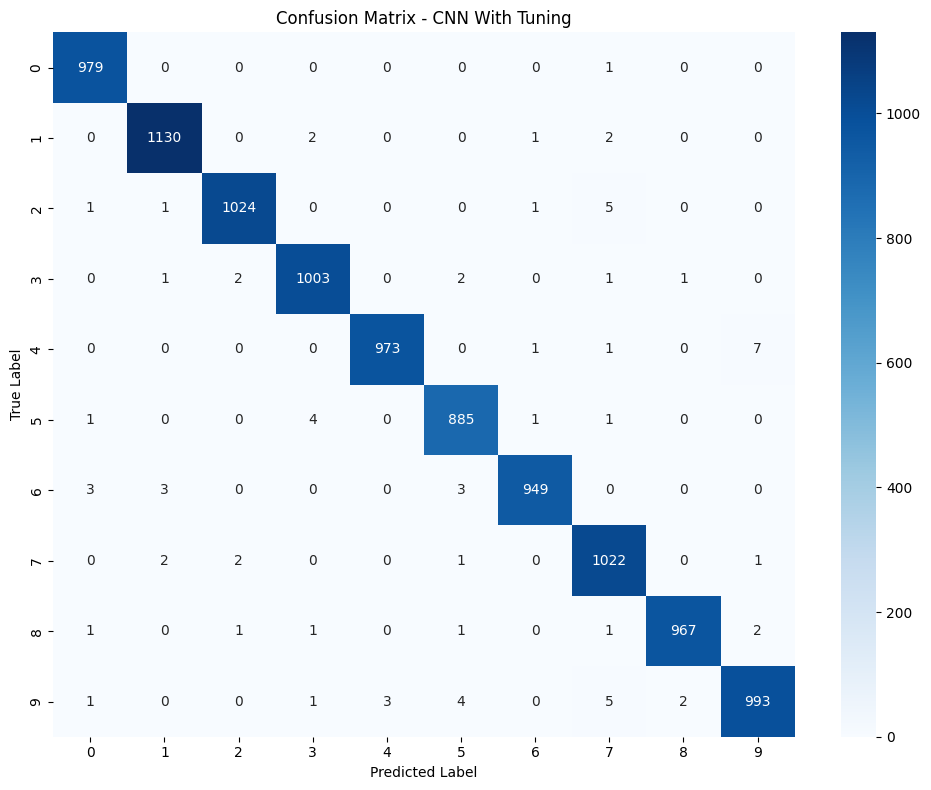

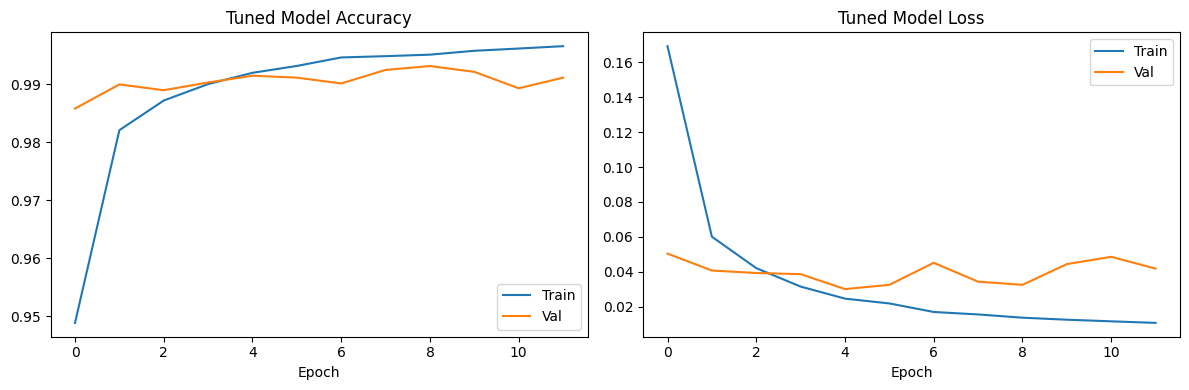

In [2]:
!pip install keras-tuner -q

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load and preprocess
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Subset for faster search
X_tune = X_train[:10000]
y_tune = y_train[:10000]

def build_model(hp):
    model = keras.Sequential()
    filters1 = hp.Choice('filters_1', [32, 64])
    model.add(layers.Conv2D(filters1, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))

    filters2 = hp.Choice('filters_2', [64, 128])
    model.add(layers.Conv2D(filters2, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())

    units = hp.Choice('dense_units', [64, 128, 256])
    model.add(layers.Dense(units, activation='relu'))

    dropout = hp.Float('dropout', 0.2, 0.5, step=0.1)
    model.add(layers.Dropout(dropout))

    model.add(layers.Dense(10, activation='softmax'))

    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    seed=42,
    directory='cnn_tuning',
    project_name='mnist_cnn'
)

print("Starting hyperparameter search (10 trials)...")
tuner.search(X_tune, y_tune, epochs=5, validation_split=0.2, verbose=0)

best_hps = tuner.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters:")
print(f"  filters_1     : {best_hps.get('filters_1')}")
print(f"  filters_2     : {best_hps.get('filters_2')}")
print(f"  dense_units   : {best_hps.get('dense_units')}")
print(f"  dropout       : {best_hps.get('dropout')}")
print(f"  learning_rate : {best_hps.get('learning_rate')}")

# Train best model on full data
best_model = tuner.hypermodel.build(best_hps)
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3,
                                            restore_best_weights=True)
history = best_model.fit(X_train, y_train, epochs=15, batch_size=32,
                         validation_split=0.1, callbacks=[early_stop], verbose=1)

print(f"\nStopped at epoch: {len(history.history['accuracy'])}")

test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred = np.argmax(best_model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - CNN With Tuning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Tuned Model Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Tuned Model Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout()
plt.show()
